In [ ]:
# Author : Charles Fredric G. Inventado 
# Year & Section : 3CSE
# Faculty and University : College of Information and Computing Sciences in University of Santo Tomas
# In Compliance with Summative Lab Exercise #1: Boston Pricing Prediction for Machine Learning 

In [9]:
#installing helpful packages from scikit-learn for machine learning and data analysis, only have to install it once if requirements are not satisfied  
!pip install scikit-learn

In [299]:
# Importing necessary libraries (pandas, numpy, matplotlib, seaborn, sklearn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy import stats

#Additional imports that were not included from the first Activity 
import csv
import csv as reader

In [301]:
# Load the boston dataset
# Boston house-price dataset, which originates from a study by Harrison, D. and Rubinfeld, D.L.

# No. of inputs : 13 ('CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT')
# One Target Variable -> MEDV: Median value of owner-occupied homes in $1000's.

data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Data ni Sir Suarez/boston (1).csv')

In [303]:
# Data Exploration
data.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [305]:
# Display the first few rows of the dataset
data.tail(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [307]:
# ----------- SAMPLE PROCEDURES DONE USING THE BOSTON DATASET DURING 1/25/2025 F2F SESSION ----------- #

In [309]:
# Selecting only 3 columns for analysis (e.g., RM, LSTAT, and MEDV)
df= data[['TAX', 'INDUS', 'MEDV']]

# including all columns for later
#df = data[['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']]

In [311]:
# Exploratory Data Analysis (EDA)
# Checking the basic statistics of the selected columns
print(df.describe())

              TAX       INDUS        MEDV
count  506.000000  506.000000  506.000000
mean   408.237154   11.136779   22.532806
std    168.537116    6.860353    9.197104
min    187.000000    0.460000    5.000000
25%    279.000000    5.190000   17.025000
50%    330.000000    9.690000   21.200000
75%    666.000000   18.100000   25.000000
max    711.000000   27.740000   50.000000


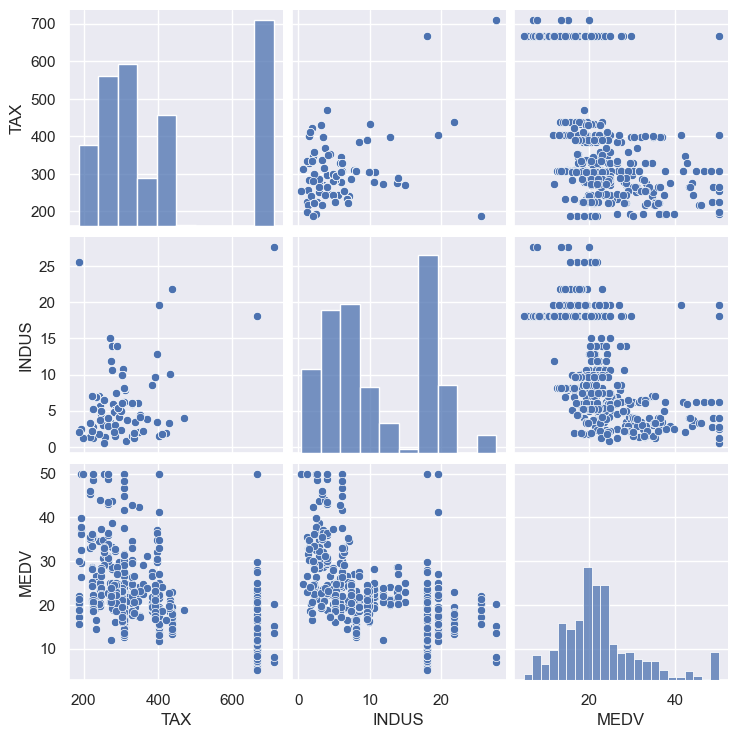

In [313]:
# Pairplot to visualize relationships between features and the target variable
sns.pairplot(df)
plt.show()

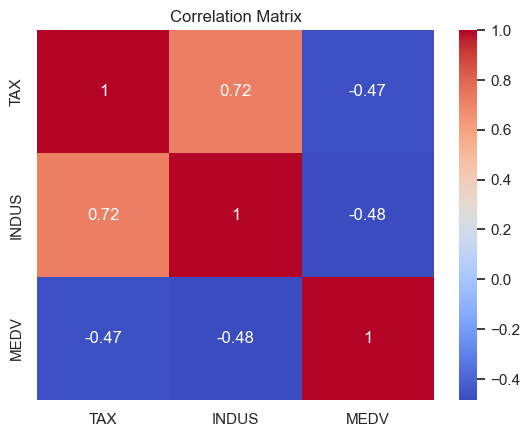

In [314]:
# Correlation matrix to understand the relationships between variables
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [317]:
# Data Preprocessing
# Checking for missing values
print(df.isnull().sum())

TAX      0
INDUS    0
MEDV     0
dtype: int64


In [319]:
# Splitting the data into training and testing sets
X = df[['TAX', 'INDUS']]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [321]:
# Feature scaling
scaler = StandardScaler()
X_train[['TAX', 'INDUS']] = scaler.fit_transform(X_train[['TAX', 'INDUS']])
X_test[['TAX', 'INDUS']] = scaler.transform(X_test[['TAX', 'INDUS']])

In [323]:
# Regression Model
# Implementing Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [325]:
# Making predictions on the test set
y_pred = model.predict(X_test)

In [327]:
# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 51.85836732617485
R-squared (R2): 0.292844783245375


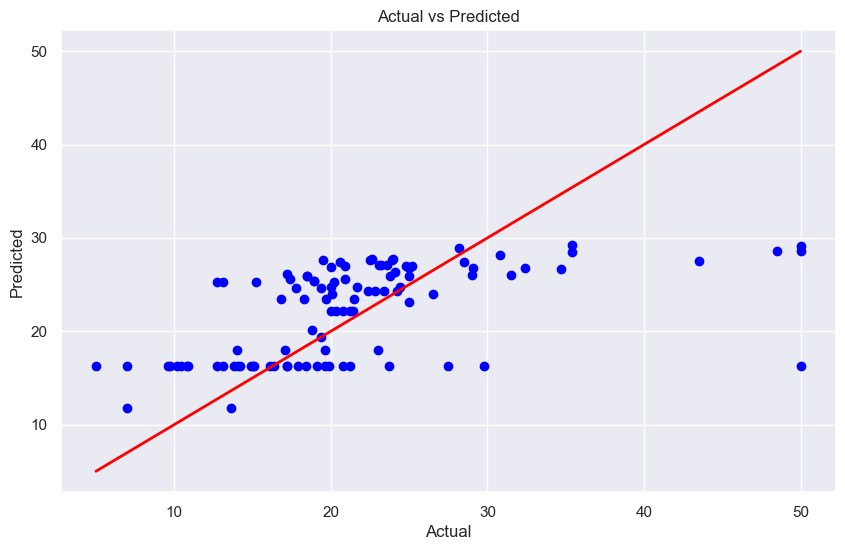

In [329]:
# Plotting the predictions vs actual values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [331]:
# ----------- END OF SAMPLE PROCEDURES FROM DONE DURING 1/25/2025 F2F SESSION ----------- #

In [333]:
# Understanding the context of this task
# GOAL : predict the median value of owner-occupied homes in Boston (MEDV) using the Boston house-price dataset.
# HOW DO WE ACHIEVE THIS GOAL? : Applying linear regression and its variants, such as Ridge Regression, Lasso Regression, etc.
# Optimize with hyperparameter tuning and obtain the most optimal values for the parameters on the advanced linear regression models.

# PRIMARY OBJECTIVES
# A - Understanding the Data
# B - Data Processing
# C - Modelling
# D - Analysis and Interpretation

# DETAILED TASK OBJECTIVES
# 1 - Exploratory Data Analysis (EDA)
# 2 - Data Preprocessing
# 3 - Model Implementation
# 4 - Model Evaluation
# 5 - Analysis and Interpretation
# 6 - Documentation

In [335]:
# SUB-SECTIONS / CONTENTS
# 1.1 Start of Perform EDA to gain insights into the data distribution and relationships between features.
# 1.2.A Visualize correlations between the input features 
# 1.2.B Visualize correlations between the input features and the target Variable (MEDV)
# 1.3.A Start of Identify and handle any missing data 
# 1.3.B start of Identify and handle any outliers.

# 2.1 Normalization/Scaling:
# 2.2 Encoding:-> for the CHAS variable
# 2.3 Feature Selection

# 3.1 Baseline Model
# 3.2.A Ridge Regression
# 3.2.B Lasso Regression
# 3.2.C Elastic Net

# 4.A Model Evaluation for Simple or Multiple Linear Regression
# 4.B Model evaluation for Ridge Regression
# 4.C Model evaluation for Lasso Regression
# 4.D Model evaluation for Elastic Net Regression
# 4.E Comparison of different regression models using the Data with removed outliers

# 4.F Hyperparameter Tuning to Ridge Regression Model
# 4.G Hyperparameter Tuning to Lasso Regression Model
# 4.H Hyperparameter Tuning to Elastic Net Regression Model
# 4.I Comparison of different regression models using the Data with hyperparameter tuning and removed outliers

# 4.J Baseline Model: Linear Regression with Outliers
# 4.K Ridge Regression with Outliers
# 4.L Lasso Regression with Outliers
# 4.M Elastic Net Regression with Outliers
# 4.N Comparison of 4 Regression Model Results without Hyperparameter Tuning and with Outliers

# 5 Analysis and Interpratation will further be detailed on Documentation, 
# but we already did all implementation of the visualizations and needed values for interpretation already on code.

In [337]:
# 1 Exploratory Data Analysis (EDA) 

In [339]:
# --------------------------------------------------------------------------------------- #
# 1.1 Perform EDA 

# We want to visualize the relationships between all the 13 input variables first
all_variables_without_target = data[['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']]
all_variables_without_target

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [341]:
# inspection of all the data types from raw data
all_variables_without_target.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
dtype: object

In [343]:
#basic statistics of all columns
print(all_variables_without_target.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

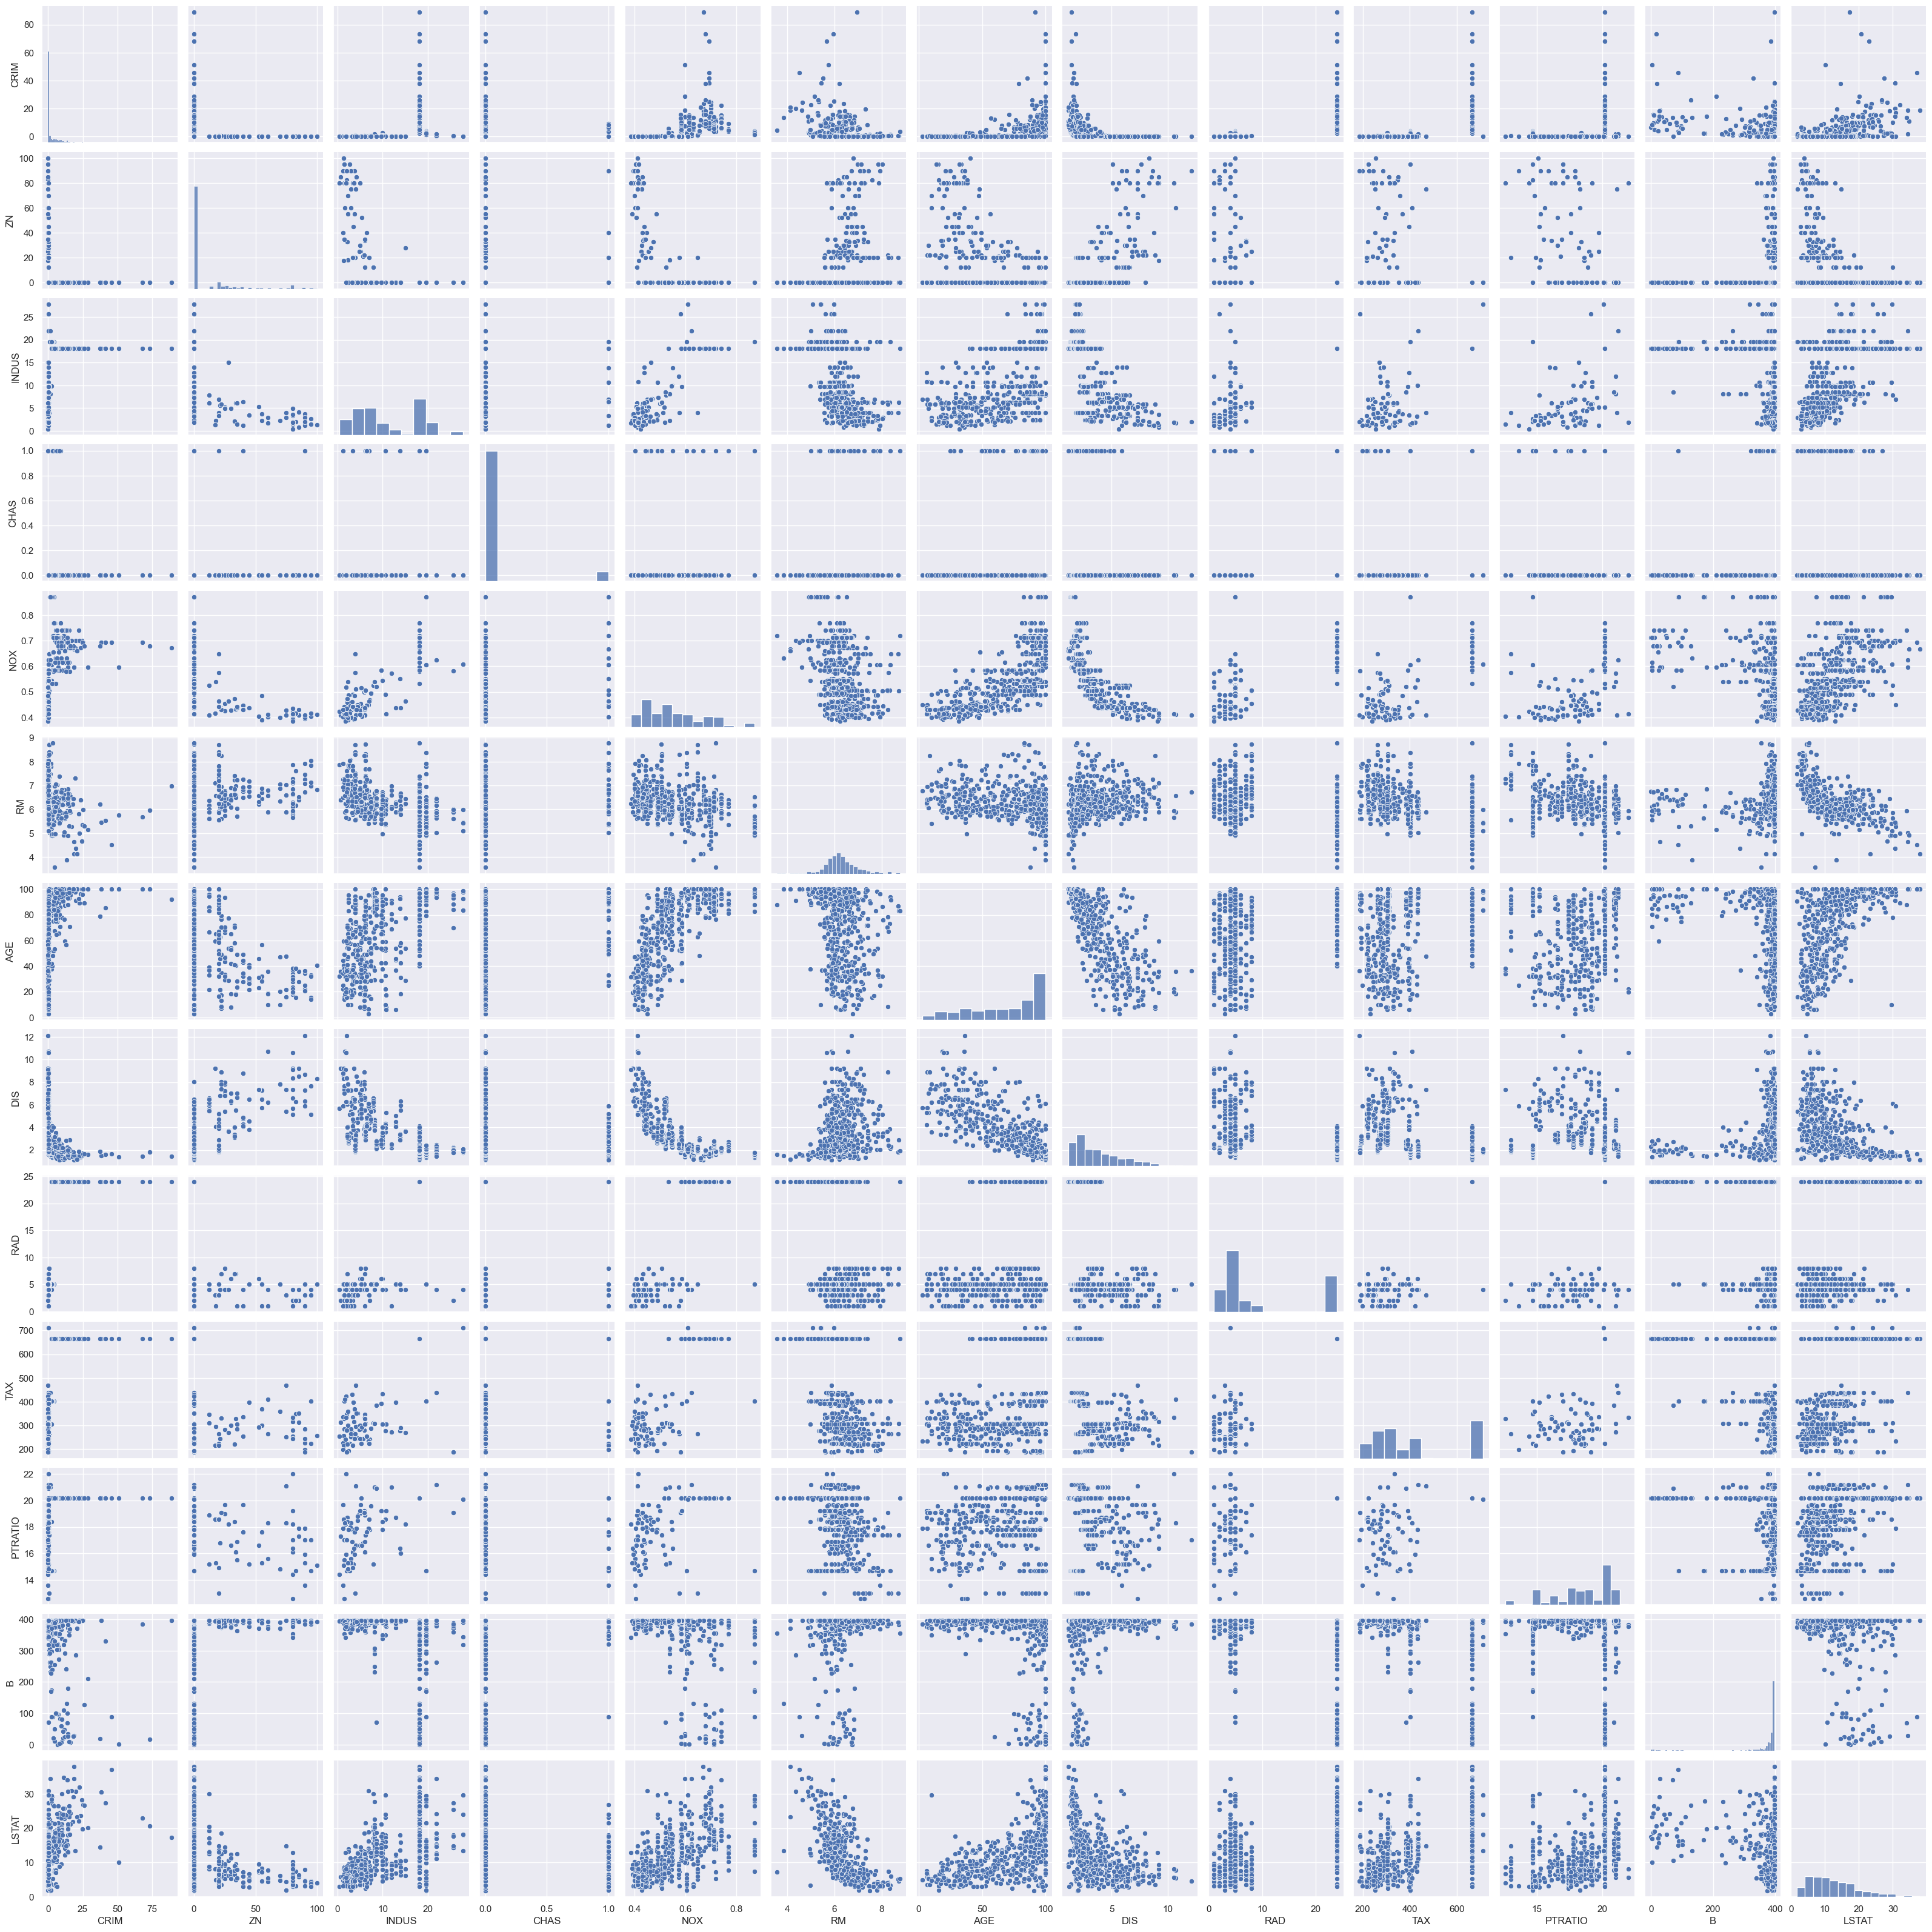

In [345]:
# --------------------------------------------------------------------------------------- #
# 1.2.A Visualize correlations between the input features 

# Pairplot of all the columns 
sns.pairplot(all_variables_without_target)
#plt.savefig('Pairplot_All_RawData.png', dpi=1200)
plt.show()

In [346]:
# The pairplot of independent variables where it looks like there is a correlation between two independent variables (visually) :

# NOX AND AGE , NOX AND DIS
# DIS AND AGE
# LSTAT AND NOUS, LSTAT AND NOX , LSTAT AND RM, LSTAT AND DIS, INDUS AND LSTAT

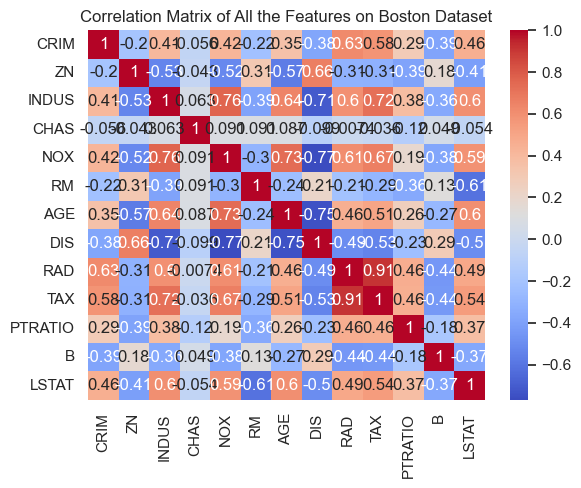

In [347]:
# Correlation matrix to understand the relationships between all the variables in the dataset
corr_matrix = all_variables_without_target.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of All the Features on Boston Dataset")
plt.savefig('Correlation_RawData_Features_And_MEDV.png', dpi=1200)
plt.show()

In [348]:
# Finding values that might have strong correlation ; strong association ; Afraid of having collinearity
corr_matrix = all_variables_without_target.corr()
threshold = 0.6
strong_corr = corr_matrix[(corr_matrix.abs() > threshold) & (corr_matrix != 1.0)]
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')
print(strong_corr)

           CRIM        ZN     INDUS       NOX        RM       AGE       DIS  \
CRIM        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
ZN          NaN       NaN       NaN       NaN       NaN       NaN  0.664408   
INDUS       NaN       NaN       NaN  0.763651       NaN  0.644779 -0.708027   
NOX         NaN       NaN  0.763651       NaN       NaN  0.731470 -0.769230   
RM          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
AGE         NaN       NaN  0.644779  0.731470       NaN       NaN -0.747881   
DIS         NaN  0.664408 -0.708027 -0.769230       NaN -0.747881       NaN   
RAD    0.625505       NaN       NaN  0.611441       NaN       NaN       NaN   
TAX         NaN       NaN  0.720760  0.668023       NaN       NaN       NaN   
LSTAT       NaN       NaN  0.603800       NaN -0.613808  0.602339       NaN   

            RAD       TAX     LSTAT  
CRIM   0.625505       NaN       NaN  
ZN          NaN       NaN       NaN  
INDUS       NaN 

In [349]:
# Higher threshold of 0.8 ; very strong association ; Afraid of having collinearity
corr_matrix = all_variables_without_target.corr()
threshold = 0.8
strong_corr = corr_matrix[(corr_matrix.abs() > threshold) & (corr_matrix != 1.0)]
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')
print(strong_corr)

          RAD       TAX
RAD       NaN  0.910228
TAX  0.910228       NaN


In [350]:
# 0.6 to 0.8 -> strong correlation
# 0.81 to 1.0 -> very strong correlation
# 1.0.1 LEARNING ------------------------- INSIGHTS ABOUT relationships between features. -------------------------
# 1.) I am afraid of the strong correlation between RAD and TAX with 0.910228 , might cause multicollinearity ; This will be considered on feature selection
# (strong relationship between two independent variables)
# 2.) I have to do a higher threshold from 0.6 to 0.8 due to a lot of features having a correlation of 0.6 to 0.8

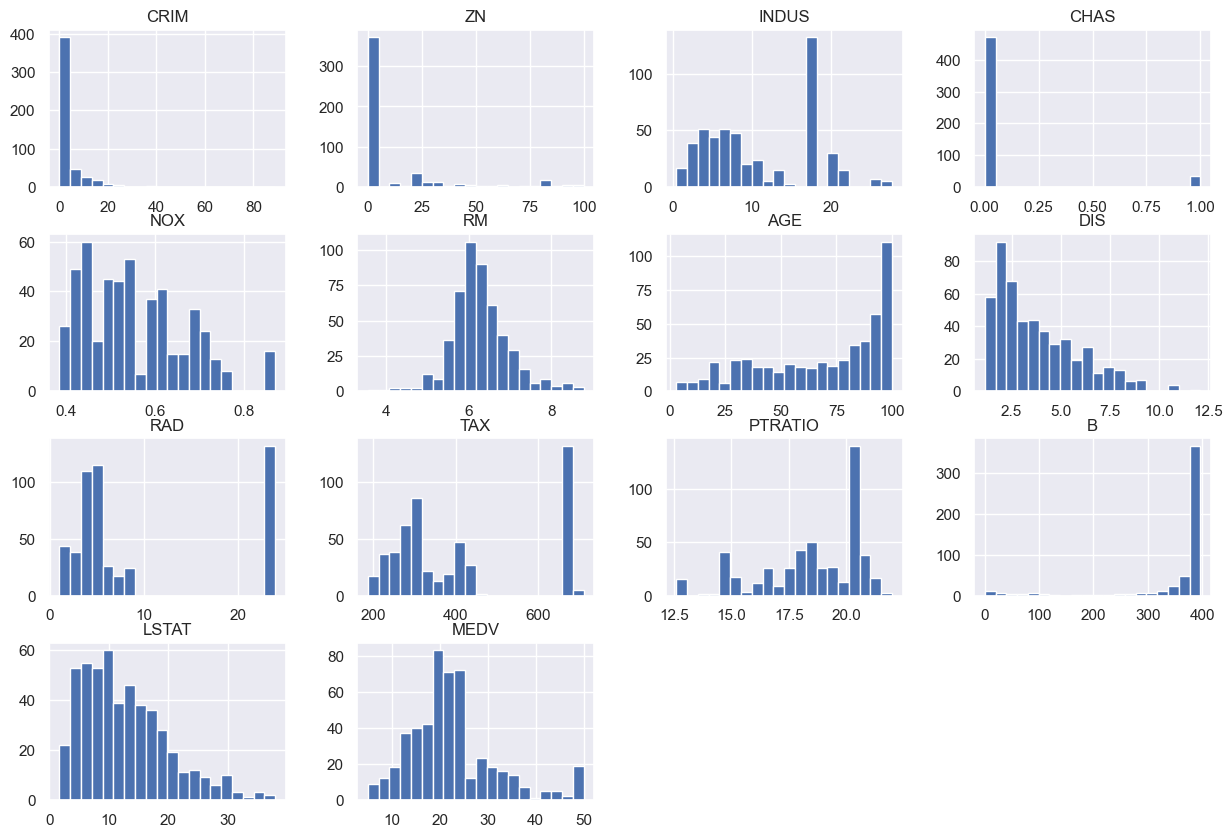

In [357]:
sns.set(font_scale=1)
data.hist(bins=20, figsize=(15,10))
plt.savefig('RawData_Distribution.png', dpi=1200)
plt.show()

In [358]:
# 1.2.A LEARNING -------------------------INSIGHTS ABOUT data distribution of featurues -------------------------
# Most data distribution on features is skewed to the right (AGE,TAX,B) or skewed to the left (CRIM, ZN, CHAS, NOX, DIS,RAD,LSTAT).
# RM looks normally distributed
# INDUS looks distributed scatteredly 

# Including also here distribution of the targeted variable : MEDV looks skewed to the left

In [359]:
# --------------------------------------------------------------------------------------- #
# 1.2.B Visualize correlations between the input features and the target Variable (MEDV)

# all 13 input variables with the target variable (MEDV)
all_variables = data[['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']]
all_variables

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


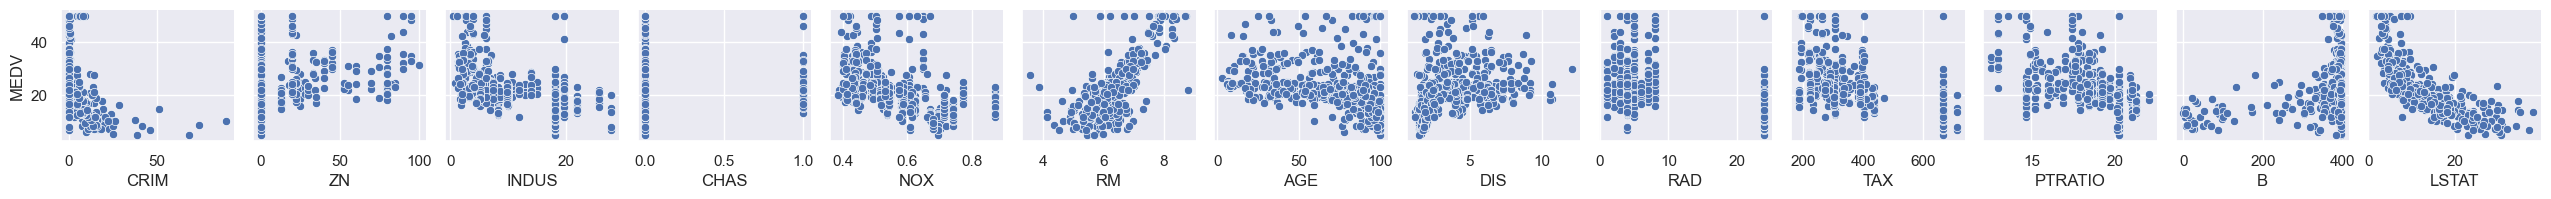

In [360]:
# Pairplot of the dependent variable MEDV (see on x-axis) to all of the features (see on y-axis)
sns.set(font_scale=1)
sns.pairplot(all_variables, 
             y_vars=['MEDV'], 
             x_vars=all_variables.columns[:-1], 
             kind='scatter', 
             height=2, aspect=1)
plt.savefig('Pairplot_DependentMEDV_With_Independent.png', dpi=1200)
plt.show()

          CRIM        ZN     INDUS     CHAS       NOX       RM       AGE  \
MEDV -0.388305  0.360445 -0.483725  0.17526 -0.427321  0.69536 -0.376955   

           DIS       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
MEDV  0.249929 -0.381626 -0.468536 -0.507787  0.333461 -0.737663   1.0  


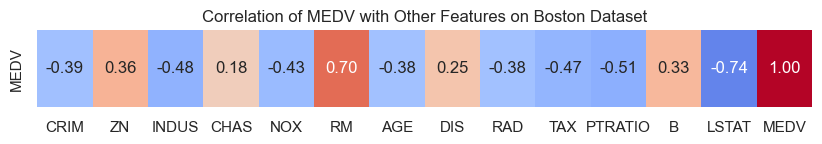

In [361]:
# Calculate the correlation matrix
corr_matrix = all_variables.corr()

# Extract only the row for MEDV
medv_corr = corr_matrix.loc[['MEDV'], :]

# Display the correlation row
print(medv_corr)

# Visualize the correlation row as a heatmap
sns.set(font_scale=1)
plt.figure(figsize=(10, 1))
sns.heatmap(medv_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title("Correlation of MEDV with Other Features on Boston Dataset")
plt.savefig('Correlation_MEDV_with_other_Features_EDAPart.png', dpi=1200)
plt.show()

In [365]:
# 1.2.B LEARNING ------------------ INSIGHTS ABOUT CORRELATION between the input features and the target variable (MEDV). -------------------------
# 1.) Notice there is a strong correlation for RM and MEDV, LSTAT and MEDV ; This is interesting and will be considered on feature selection

In [366]:
# ------------------------------------------- NEW SUB-SECTION ---------------------------------------------
# 1.3.A Start of Identify and handle any missing data 
# Identify and handle any missing data
all_variables.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [367]:
# 1.3 LEARNING ------------------------- INSIGHTS ABOUT MISSING VALUES OF THE DATASET -------------------------
# 1.) No much problem regarding missing values on the cells
# 2.) The value data types fits the need of linear regression models, the technically categorical one (CHAS) is already converted to numerical value 
# 3.) There is no need for management regarding missing values

In [373]:
# --------------------------------------------------------------------------------------- #
# 1.3.B start of Identify and handle any outliers.

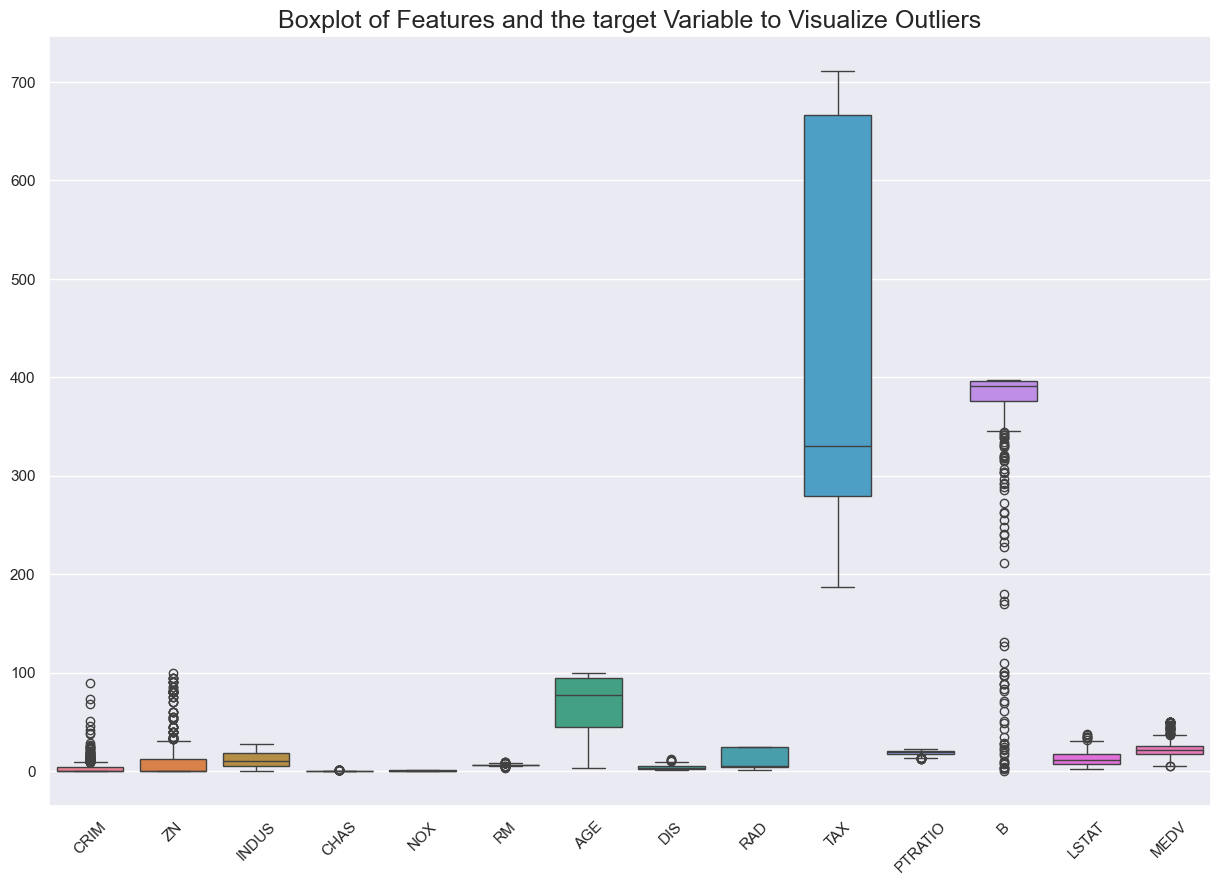

In [383]:
#set font scale
sns.set(font_scale=1)

# Create a boxplot for each column
sns.boxplot(data=all_variables)
sns.set(rc={'figure.figsize':(15,10)}, font_scale=1.5, style='whitegrid')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set title
plt.title("Boxplot of Features and the target Variable to Visualize Outliers")

#Save image
#plt.savefig('Visualize_Outliers_Target_And_Features.png', dpi=1200)

# Show plot
plt.show()

In [385]:
# 1.3.B LEARNING ------------------------- INSIGHTS ABOUT OUTLIERS OF THE DATASET -------------------------
# 1.) Features CRIM, ZN, CHAS, RM, DIS, PTRATIO, B, LSTAT, and MEDV definitely contains outliers
# 2.) The columns with the worst outliers seems to be CRIM, ZN, and B, this can definitely skewed my data analysis.

In [387]:
# Handling the outliers

In [389]:
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

# Check dataset size after removing outliers
print(f"Dataset size after removing outliers: {df_cleaned.shape}")


Dataset size after removing outliers: (268, 14)


In [391]:
# Considering the outliers from all of the columns on the dataset will decrease the number of records by half, so we won't pursue on this method.
# Therefore, we must only consider removing outliers from some with the worst outliers such as B, CRIM, and ZN

In [393]:
# Function to detect outliers using IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# Detect outliers for each numerical column
outliers = data.apply(detect_outliers_iqr)
outlier_counts = outliers.sum()

# Display outlier counts per feature
print("Outlier counts per feature:\n", outlier_counts)

# Select features with many outliers (more than 10% of rows)
high_outlier_features = outlier_counts[outlier_counts > (0.1 * len(data))].index.tolist()
print("\nFeatures with many outliers:", high_outlier_features)

Outlier counts per feature:
 CRIM       66
ZN         68
INDUS       0
CHAS       35
NOX         0
RM         30
AGE         0
DIS         5
RAD         0
TAX         0
PTRATIO    15
B          77
LSTAT       7
MEDV       40
dtype: int64

Features with many outliers: ['CRIM', 'ZN', 'B']


In [395]:
# CRIM, ZN, and B indeed has a lot of outliers.

In [397]:
df = data[['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']]

In [399]:
#df.columns

In [401]:
# Function to remove outliers using IQR for selected features
def remove_outliers_iqr(df, features):
    df_cleaned = df.copy()  # Create a copy to avoid modifying the original dataframe
    for col in features:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]  # Update df_cleaned
    return df_cleaned  # Return the cleaned dataframe

# List of columns to remove outliers from
outlier_columns = ['CRIM', 'ZN', 'B']  # Use a list of column names

# Apply outlier removal to selected features
df_cleaned = remove_outliers_iqr(df, outlier_columns)

print(f"\nDataset size after removing outliers from features CRIM, ZN, and B: {df_cleaned.shape}")



Dataset size after removing outliers from features CRIM, ZN, and B: (346, 14)


In [403]:
#number of records that can be removed due to outliers from CRIM, ZN, and B
print(506-346)

160


In [405]:
# 1.3.B v2 LEARNING ------------------------- INSIGHTS ABOUT OUTLIERS (PART 2) OF THE DATASET -------------------------
# 1.) I am so unsure yet of I will remove the outliers from CRIM, ZN, and B due to a lot of records may be removed with this process. 
# 2.) 160 records will be lost at least if this process is continued

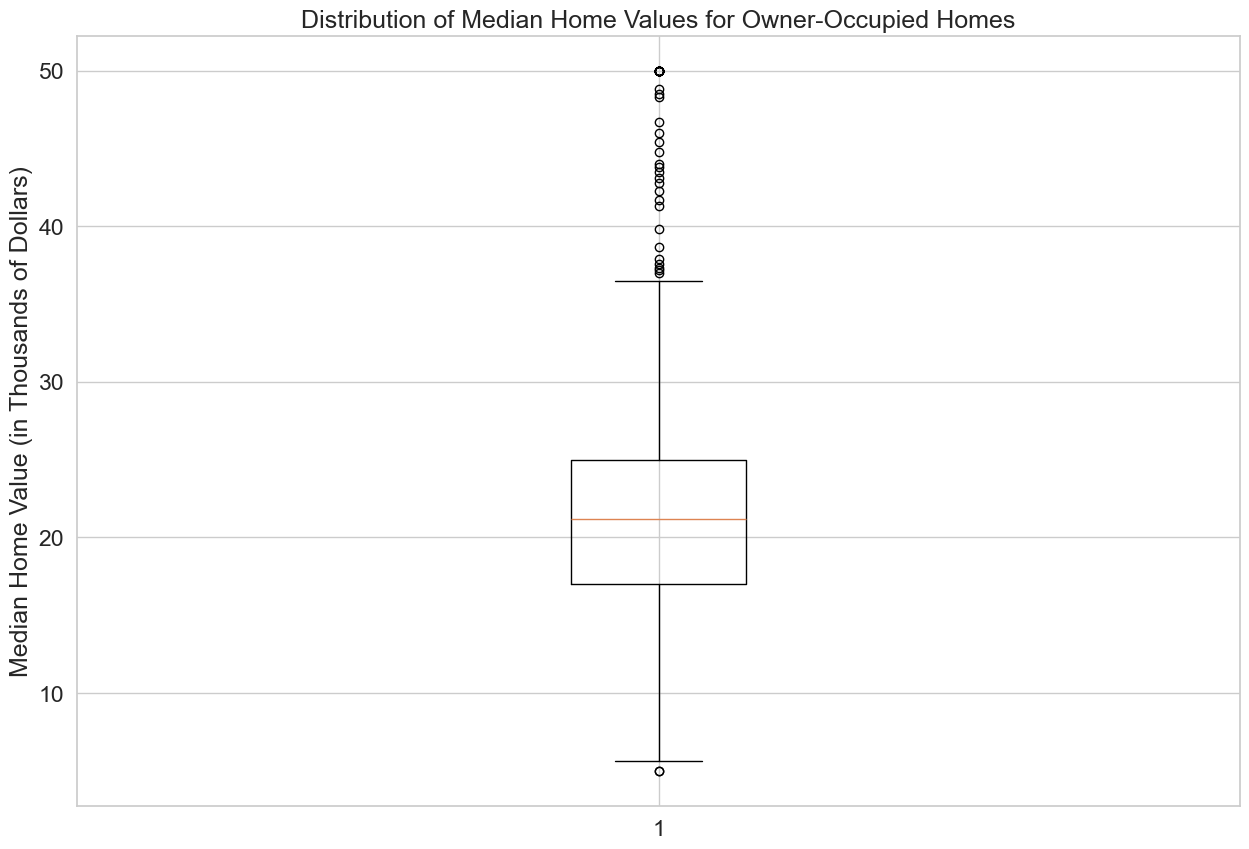

In [407]:
#boxplot to visualize distribution of median home values for owner-occupied homes; finding the outliers
plt.boxplot(data['MEDV'],)
plt.title('Distribution of Median Home Values for Owner-Occupied Homes')
plt.ylabel('Median Home Value (in Thousands of Dollars)')
#plt.savefig('Boxplot_Distribution_MedianHomeValues_RawData.png', dpi=1200)
plt.show()

In [409]:
# Furthermore, we are experimenting. In the end, we will remove the outliers from the dependent variable MEDV.

# Detecting outliers through IQR method
# https://www.geeksforgeeks.org/detect-and-remove-the-outliers-using-python/

# Load the dataset
data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Data ni Sir Suarez/boston (1).csv')

# Furthermore, we are experimenting. In the end, we will remove the outliers from the dependent variable MEDV.

# Calculate Q1, Q3, and IQR for MEDV
Q1 = data['MEDV'].quantile(0.25)
Q3 = data['MEDV'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to remove outliers in MEDV
df_cleaned = data[(data['MEDV'] >= lower_bound) & (data['MEDV'] <= upper_bound)]

# Save the cleaned dataset
df_cleaned.to_csv('boston_cleaned_without_MEDV_outliers.csv', index=False)

# Print the number of rows removed
print(f"Number of rows removed: {len(data) - len(df_cleaned)}")
print(f"Original dataset size: {len(data)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

Number of rows removed: 40
Original dataset size: 506
Cleaned dataset size: 466


In [411]:
# Furthermore, we are experimenting. In the end, we will remove the outliers from the dependent variable MEDV.

# Detecting outliers through IQR method
# https://www.geeksforgeeks.org/detect-and-remove-the-outliers-using-python/

# Load the dataset
data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Data ni Sir Suarez/boston (1).csv')

# List of columns to check for outliers (Previous boxplot of all columns, these are the columns where there is a circle present (outliers) on visual)
columns = ['CRIM','ZN','INDUS','CHAS','RM','DIS','PTRATIO','B','LSTAT','MEDV']

# Calculate Q1, Q3, and IQR for each column and filter out the outliers
for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds for each column
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out rows where the value in this column is an outlier
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Save the cleaned dataset
data.to_csv('boston_cleaned_without_outliers_2.csv', index=False)

# Print the number of rows removed
print(f"Number of rows removed: {len(df_cleaned)-len(data)}")
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(data)}")


Number of rows removed: 206
Original dataset size: 506
Cleaned dataset size: 260


In [413]:
# 1 --------------- END OF Exploratory Data Analysis (EDA) --------------- # 

In [415]:
# 2 --------------- START OF Data Preprocessing -------------------------- #

In [417]:
# Filtered data from removing outliers from MEDV
data = pd.read_csv("C:/Users/Charles Inventado/Downloads/Machine ni Sir Suarez/boston_cleaned_without_outliers_2.csv")

In [419]:
# Filtered data count is 260
print(data.describe())

             CRIM          ZN       INDUS   CHAS         NOX          RM  \
count  260.000000  260.000000  260.000000  260.0  260.000000  260.000000   
mean     0.965998    5.713462   10.317423    0.0    0.526242    6.190877   
std      1.929313   11.454106    6.167100    0.0    0.089140    0.387048   
min      0.006320    0.000000    1.250000    0.0    0.409000    4.973000   
25%      0.082382    0.000000    5.860000    0.0    0.449000    5.926750   
50%      0.160735    0.000000    8.140000    0.0    0.515000    6.148000   
75%      0.518123    0.000000   13.920000    0.0    0.573000    6.434000   
max      8.716750   45.000000   27.740000    0.0    0.871000    7.412000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  260.000000  260.000000  260.000000  260.000000  260.000000  260.000000   
mean    63.893846    4.118123    7.053846  364.823077   18.859615  389.608154   
std     26.744482    1.766543    6.752447  138.375432    1.699223   10.0

In [421]:
# --------------------------------------------------------------------------------------- #
# 2.1 Normalization/Scaling:
# Apply appropriate scaling techniques to ensure the features are on a similar scale, which is crucial for linear models

In [423]:
# 2.1 Using StandardScaler to standardize continuous data

# Separate features into continuous and categorical
continuous_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS','RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'] # Excluding MEDV ; RAD is continuous
categorical_features = ['CHAS']

# Initialize the scaler
scaler = StandardScaler()

# Apply the scaler to the continuous features
data[continuous_features] = scaler.fit_transform(data[continuous_features])

# Check the scaled data
print(data.head())

# The data is now scaled for linear models

       CRIM        ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
0 -0.498379  1.074744 -1.300914     0  0.132164  0.994357  0.048932 -0.015950   
1 -0.487479 -0.499775 -0.527588     0 -0.643392  0.595706  0.562176  0.481514   
2 -0.486160 -0.499775 -1.322034     0 -0.767031  0.619004 -0.194577  1.102621   
3 -0.455811  0.593641 -0.397617     0 -0.025195 -0.463048  0.101381  0.818072   
4 -0.426594  0.593641 -0.397617     0 -0.025195 -0.048866  1.206539  1.039268   

       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
0 -0.89827 -0.498324 -2.098889  0.728304 -1.430063  24.0  
1 -0.74989 -0.889319 -0.624791  0.728304 -0.493515  21.6  
2 -0.60151 -1.034133 -0.094115  0.450640 -1.378283  28.7  
3 -0.30475 -0.389714 -2.157853  0.598461  0.247169  22.9  
4 -0.30475 -0.389714 -2.157853  0.728304  1.760054  27.1  


In [425]:
# --------------------------------------------------------------------------------------- #
# 2.2 Encoding:  -> for the CHAS variable
# Handle categorical variables (if any) using suitable encoding methods.

# 2.2 Handle Label Encoding for binary categorical variables (CHAS)
label_encoder = LabelEncoder()
data['CHAS'] = label_encoder.fit_transform(data['CHAS'])  # 0 for no, 1 for yes

# No encoding needed for RAD, since it is continuous data
# Just ensure that the data is in the correct form, and no encoding is applied here

# Check the data after encoding
print(data.head())

# The data now has CHAS encoded, and RAD is left as continuous data

       CRIM        ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
0 -0.498379  1.074744 -1.300914     0  0.132164  0.994357  0.048932 -0.015950   
1 -0.487479 -0.499775 -0.527588     0 -0.643392  0.595706  0.562176  0.481514   
2 -0.486160 -0.499775 -1.322034     0 -0.767031  0.619004 -0.194577  1.102621   
3 -0.455811  0.593641 -0.397617     0 -0.025195 -0.463048  0.101381  0.818072   
4 -0.426594  0.593641 -0.397617     0 -0.025195 -0.048866  1.206539  1.039268   

       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
0 -0.89827 -0.498324 -2.098889  0.728304 -1.430063  24.0  
1 -0.74989 -0.889319 -0.624791  0.728304 -0.493515  21.6  
2 -0.60151 -1.034133 -0.094115  0.450640 -1.378283  28.7  
3 -0.30475 -0.389714 -2.157853  0.598461  0.247169  22.9  
4 -0.30475 -0.389714 -2.157853  0.728304  1.760054  27.1  


In [427]:
# TLDR; 

#StandardScaler for features except CHAS, excluded MEDV on transform.
#Encoding did LabelEncoding to CHAS

In [429]:
# Saving the transformed (scaled) dataset to a new .csv file
data.to_csv('boston_cleaned_without_MEDV_outliers_scaled_encoded.csv', index=False)

In [431]:
# --------------------------------------------------------------------------------------- #
# 2.3 Feature Selection

# 2.3 Analyze feature importance and potentially reduce dimensionality by selecting relevant features.

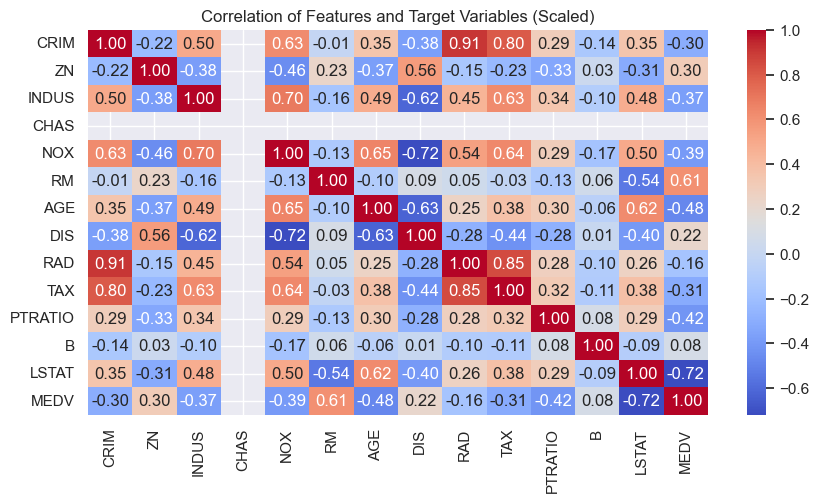

MEDV       1.000000
RM         0.607667
ZN         0.301555
DIS        0.218245
B          0.082446
RAD       -0.163868
CRIM      -0.302918
TAX       -0.313865
INDUS     -0.371899
NOX       -0.393572
PTRATIO   -0.418411
AGE       -0.483831
LSTAT     -0.717989
CHAS            NaN
Name: MEDV, dtype: float64


In [433]:
# Doing Correlation Matrix Analysis

#Calculate correlation matrix
correlation_matrix = data.corr()

# Plot heatmap of correlations
sns.set(font_scale=1)
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation of Features and Target Variables (Scaled)')
plt.savefig('Correlation_ScaledTransformed_WithoutCHAS.png', dpi=1200)
plt.show()

# Display the features most correlated with the target (MEDV)
target_corr = correlation_matrix['MEDV'].sort_values(ascending=False)
print(target_corr)

In [434]:
# Print features with strong correlation (absolute correlation > 0.6)
strong_corr = target_corr[abs(target_corr) > 0.6]
print("Features with strong correlation with MEDV:")
print(strong_corr)

Features with strong correlation with MEDV:
MEDV     1.000000
RM       0.607667
LSTAT   -0.717989
Name: MEDV, dtype: float64


In [435]:
# Repeated the code before from independent variables correlation matrix
# Finding values that might have strong correlation ; strong association ; Afraid of having collinearity
corr_matrix = all_variables_without_target.corr()
threshold = 0.6
strong_corr = corr_matrix[(corr_matrix.abs() > threshold) & (corr_matrix != 1.0)]
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')
print(strong_corr)

           CRIM        ZN     INDUS       NOX        RM       AGE       DIS  \
CRIM        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
ZN          NaN       NaN       NaN       NaN       NaN       NaN  0.664408   
INDUS       NaN       NaN       NaN  0.763651       NaN  0.644779 -0.708027   
NOX         NaN       NaN  0.763651       NaN       NaN  0.731470 -0.769230   
RM          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
AGE         NaN       NaN  0.644779  0.731470       NaN       NaN -0.747881   
DIS         NaN  0.664408 -0.708027 -0.769230       NaN -0.747881       NaN   
RAD    0.625505       NaN       NaN  0.611441       NaN       NaN       NaN   
TAX         NaN       NaN  0.720760  0.668023       NaN       NaN       NaN   
LSTAT       NaN       NaN  0.603800       NaN -0.613808  0.602339       NaN   

            RAD       TAX     LSTAT  
CRIM   0.625505       NaN       NaN  
ZN          NaN       NaN       NaN  
INDUS       NaN 

In [436]:
# Repeated the code before from independent variables correlation matrix
# Higher threshold of 0.8 ; very strong association ; Afraid of having collinearity
corr_matrix = all_variables_without_target.corr()
threshold = 0.8
strong_corr = corr_matrix[(corr_matrix.abs() > threshold) & (corr_matrix != 1.0)]
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')
print(strong_corr)

          RAD       TAX
RAD       NaN  0.910228
TAX  0.910228       NaN


          CRIM        ZN     INDUS     CHAS       NOX       RM       AGE  \
MEDV -0.388305  0.360445 -0.483725  0.17526 -0.427321  0.69536 -0.376955   

           DIS       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
MEDV  0.249929 -0.381626 -0.468536 -0.507787  0.333461 -0.737663   1.0  


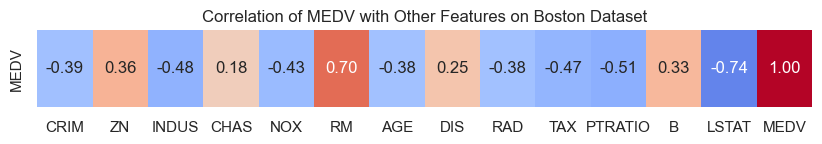

In [441]:
# FOR JUST CHAS VISIBILITY PURPOSES using code more above before it is transformed -> low correlation to MEDV , so it is not NaN
# Calculate the correlation matrix
corr_matrix = all_variables.corr()

# Extract only the row for MEDV
medv_corr = corr_matrix.loc[['MEDV'], :]

# Display the correlation row
print(medv_corr)

# Visualize the correlation row as a heatmap
sns.set(font_scale=1)
plt.figure(figsize=(10, 1))
sns.heatmap(medv_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title("Correlation of MEDV with Other Features on Boston Dataset")
plt.savefig('Correlation_MEDV_toOtherFeatures_ScaledTransformed.png', dpi=1200)
plt.show()

          CRIM        ZN     INDUS  CHAS       NOX        RM       AGE  \
MEDV -0.302918  0.301555 -0.371899   NaN -0.393572  0.607667 -0.483831   

           DIS       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
MEDV  0.218245 -0.163868 -0.313865 -0.418411  0.082446 -0.717989   1.0  


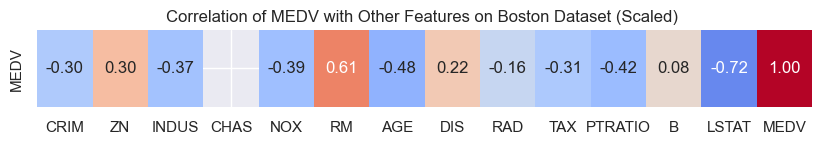

In [442]:
# TRANSFORMED DATASET , CORRELATION OF DEPENDENT VARIABLE MEDV TO OTHER FEATURES
# Calculate the correlation matrix
corr_matrix = data.corr()

# Extract only the row for MEDV
medv_corr = corr_matrix.loc[['MEDV'], :]
# Display the correlation row
print(medv_corr)

# Visualize the correlation row as a heatmap
sns.set(font_scale=1)
plt.figure(figsize=(10, 1))
sns.heatmap(medv_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title("Correlation of MEDV with Other Features on Boston Dataset (Scaled) ")
plt.savefig('Correlation_MEDV_toOtherFeatures_ScaledTransformedReal.png', dpi=1200)
plt.show()

In [444]:
# 2.3 LEARNING ---------------
# RM and LSTAT has a strong correlation to the MEDV with values 0.61 and -0.72, respectively
# Meanwhile, B has a very low correlation to MEDV with 0.08 ; This applies also CHAS with
#    -> This is a sign that we could remove B as it does not much effect the median house-price of homes

# -> Planning to drop one or both of the RAD or TAX columns ; They have strong multicollinearity of 0.91 .
# TLDR : 
# 1 - Dropping B (Low correlation with MEDV only 0.08) , 
# 2 -Dropping CHAS (Actually have correlation matrix before being NaN its just 0.18 so can be removed)
# 3 - Might as well drop CRIM because it has 0.81 correlation to TAX and 0.91 correlation to RAD , 
## where TAX and RAD already have correlation to each other , so might drop CRIM as well.
# no.4 CRIM rise on correlation to TAX and RAD changes only occured after the data scaling to using StandardScaler() , 
### it was around 0.63 and 0.58 before, respectively
# 4 - Dropping one of RAD or TAX (high feature correlation),
# Remove B,CHAS,RAD,CRIM

In [447]:
# Removing the respective columns B,CHAS,RAD,DIS,CRIM
# Drop specified columns
data_cleaned = data.drop(columns=['B', 'CHAS', 'RAD', 'CRIM'])

# Save the cleaned dataset to a new CSV file
data_cleaned.to_csv('boston_selected_features_withDIS.csv', index=False)

# Print confirmation
print("Dataset saved successfully with selected features!")
print(f"New dataset shape: {data_cleaned.shape}")

Dataset saved successfully with selected features!
New dataset shape: (260, 10)


In [449]:
data_cleaned.head()

,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,1.074744,-1.300914,0.132164,0.994357,0.048932,-0.015950,-0.498324,-2.098889,-1.430063,24.0
1,-0.499775,-0.527588,-0.643392,0.595706,0.562176,0.481514,-0.889319,-0.624791,-0.493515,21.6
2,-0.499775,-1.322034,-0.767031,0.619004,-0.194577,1.102621,-1.034133,-0.094115,-1.378283,28.7
3,0.593641,-0.397617,-0.025195,-0.463048,0.101381,0.818072,-0.389714,-2.157853,0.247169,22.9
4,0.593641,-0.397617,-0.025195,-0.048866,1.206539,1.039268,-0.389714,-2.157853,1.760054,27.1


In [451]:
# 2 --------------- END OF Data Preprocessing -------------------------- #

In [453]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [455]:
# 3 --------------- START OF Model Implementation ---------------------- #

In [457]:
# Columns with filtered data and transformed.
data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Machine ni Sir Suarez/boston_selected_features_withDIS.csv')

In [459]:
# Splitting the data into training and testing sets. (Remember self : Only use the Features Selected on X)
X = data[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']]
y = data['MEDV']

In [461]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=61)

In [463]:
# Feature scaling
scaler = StandardScaler()
X_train[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']] = scaler.fit_transform(X_train[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']])
X_test[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']] = scaler.transform(X_test[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']])

In [465]:
# --------------------------------------------------------------------------------------- #
# 3.1 Baseline Model :
lr = LinearRegression()
lr.fit(X_train, y_train)  # Train the model on the training data
y_pred_lr = lr.predict(X_test)

In [467]:
# The baseline Model is the Linear Regression Model , a starting points before we proceed with more advanced models
# Advanced Models : Ridge Regression, Lasso Regression, Elastic Net Regression
# Notice that we don't have parameters needed for linear regression model such as the alpha and l_ratio.

In [469]:
# --------------------------------------------------------------------------------------- #
# 3.2.A Ridge Regression
ridge = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 10.0]}  # Hyperparameters to be tuned
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5)  # cross-validation to find the best alpha
ridge_cv.fit(X_train, y_train)  # Fit the model using the best alpha found
y_pred_ridge = ridge_cv.predict(X_test)  # Predict the target values using the test set

In [471]:
# https://www.ibm.com/think/topics/ridge-regression
# Ridge regression can solve issued such as overfitting of training data.
# Mentions also the multicollinearity -> but we have deal with the RAD and TAX variable issue before.
# Good on ealing with a lot of features -> but we reduced already some of the columns from feauture selection

In [473]:
# --------------------------------------------------------------------------------------- #
# 3.2.B Lasso Regression
lasso = Lasso()
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)

In [475]:
# https://www.ibm.com/think/topics/lasso-regression
# increases accuracy of the model
# reduces errors caused by overfitting like Ridge
# smaller values of alpha contains more of the features
# alpha = minimizes MSE or other performance metrics 
# increase on model bias and decrease on variance on higher values of alpha
# coefficients can shrink to zero on large values of alpha
# best alpha values can be find with cross-validation

In [477]:
# --------------------------------------------------------------------------------------- #
# 3.2.C Elastic Net
elastic_net = ElasticNet()
elastic_params = {'alpha': [0.1, 1.0, 10.0, 100.0], 'l1_ratio': [0.1, 0.5, 0.7, 0.9]}
elastic_cv = GridSearchCV(elastic_net, elastic_params, cv=5) 
elastic_cv.fit(X_train, y_train)
y_pred_elastic = elastic_cv.predict(X_test)

In [479]:
#https://www.ibm.com/docs/en/spss-statistics/saas?topic=features-linear-elastic-net-regression
# estimates the regularized linear regression models
# L1 is Lasso , L2 is Ridge representing their penalties. 0.5 l-ratio gives a balance of both regression types

In [481]:
# https://www.projectpro.io/recipes/find-optimal-parameters-using-gridsearchcv-for-regression#:~:text=To%20get%20the%20best%20set,after%20passing%20in%20the%20model.
# Regarding gridsearch
# # Grid search does the combination of hyperparameters into the model and gives us the best set of 
# values/hyperparameters that can give the best result from the model

In [483]:
# 4 ------ MODEL EVALUATION -------

In [485]:
# Define a function to evaluate and print model performance
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    return mse, rmse, r2

Linear Regression - MSE: 5.07, RMSE: 2.25, R²: 0.80


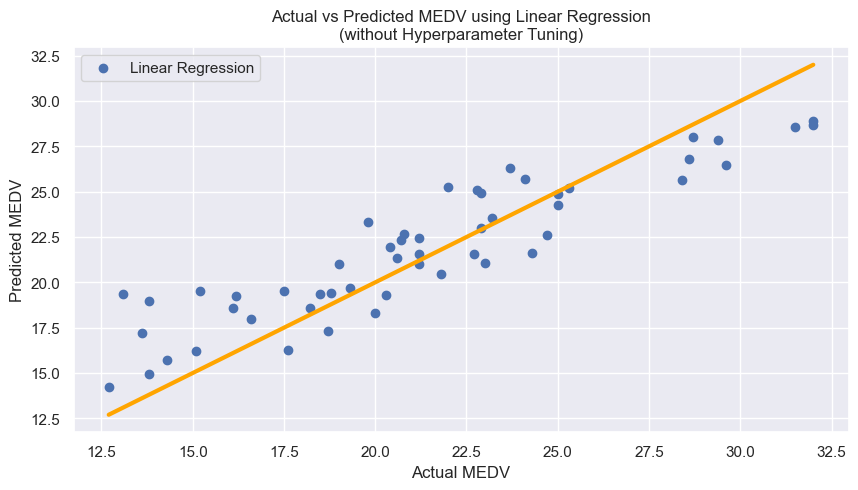

In [487]:
# --------------------------------------------------------------------------------------- #
# 4.A Model Evaluation for Simple or Multiple Linear Regression
mse_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Plot predictions vs actuals
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Actual vs Predicted MEDV using Linear Regression\n(without Hyperparameter Tuning)')
plt.savefig('Scatterplot_LinearRegression_WithoutHT_TransformScaled.png', dpi=1200)
plt.show()

In [489]:
# Best result we can get for linear regression model for R^2 = 0.80, random_state = 61 gives the best result (we have bruteforced our way
# manually so we are going to use that value)

Ridge Regression - MSE: 5.28, RMSE: 2.30, R²: 0.79


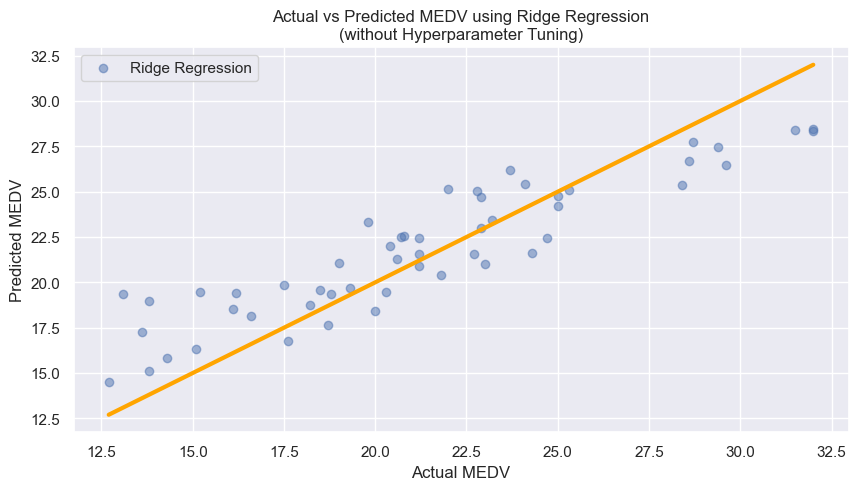

In [491]:
# ------------------------------------------- NEW SUB-SECTION --------------------------------------------- #
# 4.B Model evaluation for Ridge Regression
mse_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

# Plot of actual and predicted values of MEDV
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Actual vs Predicted MEDV using Ridge Regression\n(without Hyperparameter Tuning)')
plt.savefig('Scatterplot_RidgeRegression_WithoutHT_TransformScaled.png', dpi=1200)
plt.show()

Lasso Regression - MSE: 5.71, RMSE: 2.39, R²: 0.77


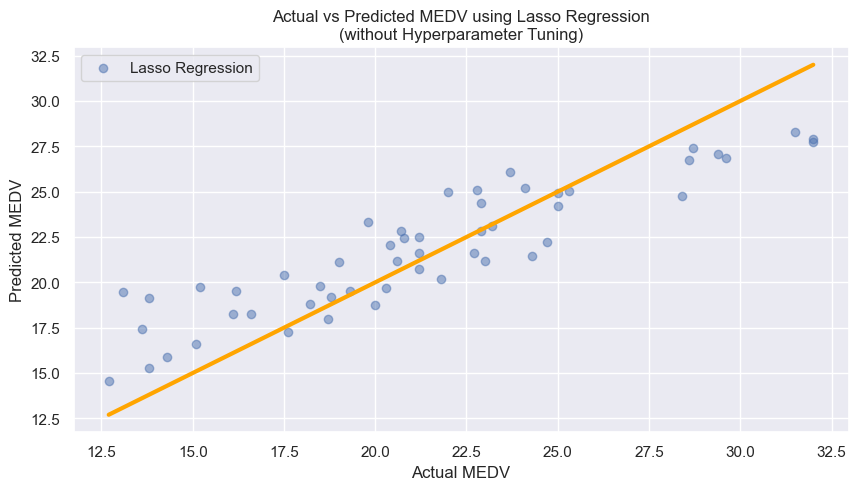

In [492]:
# --------------------------------------------------------------------------------------- #
# 4.C Model evaluation for Lasso Regression
mse_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

# Plot predictions vs actuals
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lasso, label='Lasso Regression', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Actual vs Predicted MEDV using Lasso Regression\n(without Hyperparameter Tuning)')
plt.savefig('Scatterplot_LassoRegression_WithoutHT_TransformScaled.png', dpi=1200)
plt.show()

In [493]:
# Higher MSE and RMSE, Lower R^2 on Lasso Regression when compared to Ridge Regression. Analysis and Results on Documentation is important. 

Elastic Net - MSE: 5.66, RMSE: 2.38, R²: 0.77


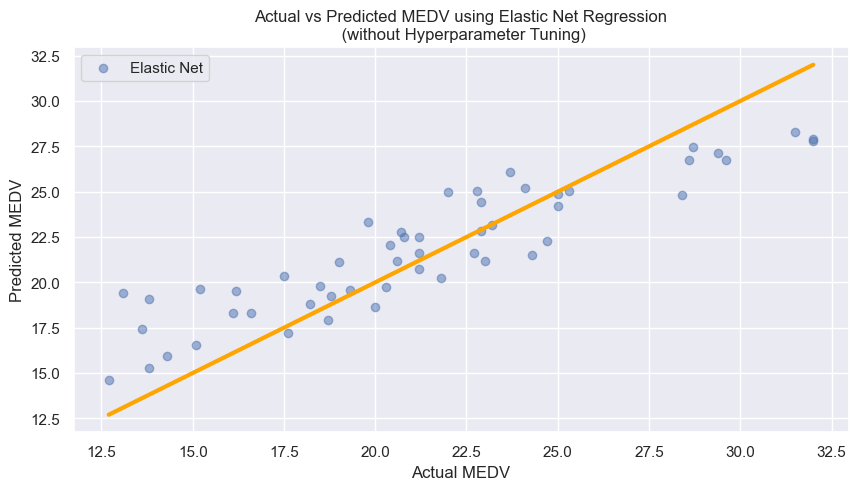

In [497]:
# --------------------------------------------------------------------------------------- #
# 4.D Model evaluation for Elastic Net Regression
mse_elastic, rmse_elastic, r2_elastic = evaluate_model(y_test, y_pred_elastic, "Elastic Net")

# Plot predictions vs actuals
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_elastic, label='Elastic Net', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Actual vs Predicted MEDV using Elastic Net Regression\n (without Hyperparameter Tuning)')
plt.savefig('Scatterplot_ElasticNet_WithoutHT_TransformScaled.png', dpi=1200)
plt.show()

In [499]:
# Improved MSE, RMSE (decrease) and R^2 (increase) when compared to Lasso Regression, but still results provided by Ridge is better 
# I did not yet include simple linear regression comparison from here, it is included below

In [501]:
# --------------------------------------------------------------------------------------- #
# 4.E Comparison of different regression models using the Data with removed outliers
mse_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression (w/o Hyperparameter Tuning)")
mse_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression (w/o Hyperparameter Tuning)")
mse_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression (w/o Hyperparameter Tuning)")
mse_elastic, rmse_elastic, r2_elastic = evaluate_model(y_test, y_pred_elastic, "Elastic Net (w/o Hyperparameter Tuning)")

Linear Regression (w/o Hyperparameter Tuning) - MSE: 5.07, RMSE: 2.25, R²: 0.80
Ridge Regression (w/o Hyperparameter Tuning) - MSE: 5.28, RMSE: 2.30, R²: 0.79
Lasso Regression (w/o Hyperparameter Tuning) - MSE: 5.71, RMSE: 2.39, R²: 0.77
Elastic Net (w/o Hyperparameter Tuning) - MSE: 5.66, RMSE: 2.38, R²: 0.77


In [503]:
# Still notice that Linear Regression Model provides the best performance or result compared to other three advanced regression models.
# Take notice on how it will change we do hyperparameterization tuning.

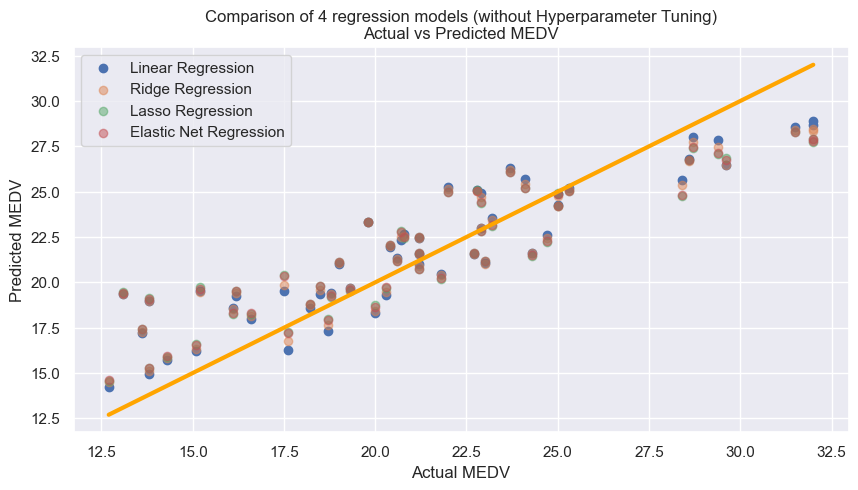

In [505]:
# Plot of the Predicted MEDV vs Actual MEDV
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.5)
plt.scatter(y_test, y_pred_lasso, label='Lasso Regression', alpha=0.5)
plt.scatter(y_test, y_pred_elastic, label='Elastic Net Regression', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Comparison of 4 regression models (without Hyperparameter Tuning)\nActual vs Predicted MEDV')
plt.savefig('Scatterplot_AllModels_WithoutHT_TransformScaled.png', dpi=1200)
plt.show()

In [506]:
# The results of the different regression models are close to one another,
# Obvious because the values of the results on MSE,RMSE, and R^2 have +- 0.1 margin only

In [507]:
# Coefficients interpretation of Regression Models without Hyperparameter Tuning.
# 4.I Coefficients of the independent variables used with Hyperparameter Tuning
feature_names = ['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']

print("Linear Regression Coefficients (w/o Hyperparameter Tuning):")
for feature, coef in zip(feature_names, lr.coef_):
    print(f"{feature}: {coef}")

print("\nRidge Regression Coefficients (w/o Hyperparameter Tuning):")
for feature, coef in zip(feature_names, ridge_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nLasso Regression Coefficients (w/o Hyperparameter Tuning):")
for feature, coef in zip(feature_names, lasso_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nElastic Net Coefficients (w/o Hyperparameter Tuning):")
for feature, coef in zip(feature_names, elastic_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

Linear Regression Coefficients (w/o Hyperparameter Tuning):
ZN: 0.09850443288013261
INDUS: -0.09374725264681655
NOX: -0.34864873654673945
RM: 1.4896300295751985
AGE: -1.1097868709080199
DIS: -1.1508681226546214
TAX: -0.1869025809923972
PTRATIO: -0.8606444057349488
LSTAT: -1.166177723618387

Ridge Regression Coefficients (w/o Hyperparameter Tuning):
ZN: 0.07251912123706908
INDUS: -0.08470471490182235
NOX: -0.3071345552354604
RM: 1.4181986887692415
AGE: -0.9900840975614247
DIS: -0.9686861653428775
TAX: -0.18518485579512298
PTRATIO: -0.8261213455966432
LSTAT: -1.1872415558880511

Lasso Regression Coefficients (w/o Hyperparameter Tuning):
ZN: 0.0
INDUS: -0.0
NOX: -0.1569084103614653
RM: 1.3757364651666069
AGE: -0.8725711995351931
DIS: -0.6341359499577516
TAX: -0.14168857884146788
PTRATIO: -0.7922383150474424
LSTAT: -1.2618160403988883

Elastic Net Coefficients (w/o Hyperparameter Tuning):
ZN: 0.0
INDUS: -0.0
NOX: -0.21401174649622093
RM: 1.3740316476469578
AGE: -0.8815104685655506
DIS: -0.

In [511]:
# Notice the coefficients really shrinked to zero on ZN and INDUS for Lasso and Elastic Net Regression.
# Meanwhile shrinking to zero does not occur on Linear and Ridge Regression Models

In [513]:
# HYPERPARAMETER TUNING 

In [515]:
# --------------------------------------------------------------------------------------- #
# 4.F Hyperparameter Tuning Applied to Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)  # Train the model on the training data
y_pred_lr = lr.predict(X_test)  # Predict the target values on the test set

In [517]:
# No changes on the linear regression model with or without Hyperparameter tuning
# because we do not have hyperparamterized values such as alpha and l_ratio here.

In [519]:
# --------------------------------------------------------------------------------------- #
# 4.G Hyperparameter Tuning Applied to Ridge Regression Model
ridge = Ridge()
ridge_params = {'alpha': [0.0001, 0.001, 0.01, 1.0, 100.0]}  # Hyperparameters to be tuned
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5)  #cross-validation to find the best alpha
ridge_cv.fit(X_train, y_train)  # Fit the model with the best alpha value we had
y_pred_ridge = ridge_cv.predict(X_test)  # Predict the target values using the test set

In [521]:
# --------------------------------------------------------------------------------------- #
# 4.H Hyperparameter Tuning Applied to Lasso Regression Model
lasso = Lasso()
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 1.0, 100.0]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5) 
lasso_cv.fit(X_train, y_train)  
y_pred_lasso = lasso_cv.predict(X_test)

In [523]:
# --------------------------------------------------------------------------------------- #
# 4.I Hyperparameter Tuning Applied to Elastic Net Regression Model
elastic_net = ElasticNet()
elastic_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 'l1_ratio': [0.2, 0.4, 0.6, 0.8]}
elastic_cv = GridSearchCV(elastic_net, elastic_params, cv=5)
elastic_cv.fit(X_train, y_train)
y_pred_elastic = elastic_cv.predict(X_test)

In [525]:
# --------------------------------------------------------------------------------------- #
# 4.J Comparison of different regression models results with Hyperparameter Tuning

# Model Comparison with Hyperparameter Tuning:
mse_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
mse_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
mse_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")
mse_elastic, rmse_elastic, r2_elastic = evaluate_model(y_test, y_pred_elastic, "Elastic Net")

Linear Regression - MSE: 5.07, RMSE: 2.25, R²: 0.80
Ridge Regression - MSE: 5.09, RMSE: 2.26, R²: 0.80
Lasso Regression - MSE: 5.13, RMSE: 2.27, R²: 0.80
Elastic Net - MSE: 5.68, RMSE: 2.38, R²: 0.77


In [527]:
# Surpsising !
# Improved MSE results across the advanced regression model results 
# (Linear, Ridge, and Lasso are now Equal in R^2) and their MSE,RMSE very tight on gaps
# Elastic Net tough, still behind on the results compared to the results of other 3 regression models.

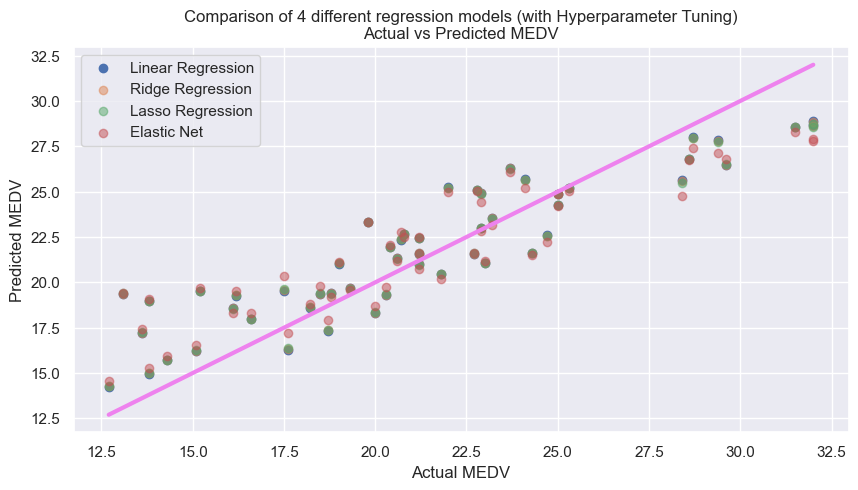

In [529]:
# Plot of the Predicted MEDV vs Actual MEDV
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.5)
plt.scatter(y_test, y_pred_lasso, label='Lasso Regression', alpha=0.5)
plt.scatter(y_test, y_pred_elastic, label='Elastic Net', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='violet', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Comparison of 4 different regression models (with Hyperparameter Tuning)\nActual vs Predicted MEDV')
plt.savefig('Scatterplot_LinearRegression_WithHT_TransformScaled.png', dpi=1200)
plt.show()

In [531]:
# Results might look similar still , because we have tried to find the best result already manually.
# But this time, conducting the evaluation with hyperparameter tuning is made easier and we are more confident we get good values of parameters.

In [533]:
# LINEAR REGRESSION WITH HYPERPARAMETER TUNING SHOWS THE BEST RESULTS SO FAR, with an improvement such as decrease on Mean Squared Error 
# and a slight increase on R^2 on some of the regression models. This will be discussed further on the documentation.

In [535]:
# --------------------------------------------------------------------------------------- #
# 4.H Coefficients of the independent variables used with Hyperparameter Tuning
feature_names = ['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']

print("Linear Regression Coefficients (with Hyperparameter Tuning):")
for feature, coef in zip(feature_names, lr.coef_):
    print(f"{feature}: {coef}")

print("\nRidge Regression Coefficients (with Hyperparameter Tuning):")
for feature, coef in zip(feature_names, ridge_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nLasso Regression Coefficients (with Hyperparameter Tuning):")
for feature, coef in zip(feature_names, lasso_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nElastic Net Coefficients (with Hyperparameter Tuning):")
for feature, coef in zip(feature_names, elastic_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

Linear Regression Coefficients (with Hyperparameter Tuning):
ZN: 0.09850443288013261
INDUS: -0.09374725264681655
NOX: -0.34864873654673945
RM: 1.4896300295751985
AGE: -1.1097868709080199
DIS: -1.1508681226546214
TAX: -0.1869025809923972
PTRATIO: -0.8606444057349488
LSTAT: -1.166177723618387

Ridge Regression Coefficients (with Hyperparameter Tuning):
ZN: 0.09507014725611901
INDUS: -0.09212821036521293
NOX: -0.3437572273105042
RM: 1.4815905139831427
AGE: -1.0955753610869232
DIS: -1.1295160242341438
TAX: -0.18672722237549247
PTRATIO: -0.8571484990687621
LSTAT: -1.169888061577681

Lasso Regression Coefficients (with Hyperparameter Tuning):
ZN: 0.07468375685769858
INDUS: -0.07744832099059548
NOX: -0.33352758927226345
RM: 1.4804579612048583
AGE: -1.0850467216308588
DIS: -1.0896186721473178
TAX: -0.18226031825470038
PTRATIO: -0.8572201378648908
LSTAT: -1.1760746833251325

Elastic Net Coefficients (with Hyperparameter Tuning):
ZN: 0.0
INDUS: -0.0
NOX: -0.19639130300699542
RM: 1.37484052721892

In [537]:
# No changes in coefficients after hyperparameter (has no hyperparameters) tuning on Linear Regression
# Obvious changes on some of the values across 3 advanced models when used with hyperparameter tuning compared to without hyperparameter tuning.
# Even the small values changed by a very small margin on the coefficients
# Lasso has now recognized coefficients, although the value of the correlation is very low.
# Again, there is Shrinking to Zero but it only occured on Elastic Net Regression, it did not happen on lasso this time.

In [539]:
# --------------------------------------------------------------------------------------- #
# 4.I Experimentation using the Raw Data (only the Independent Variable used Columns) , outliers have not been removed yet.
# Raw data
data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Data ni Sir Suarez/boston (1).csv')

In [541]:
# Feature scaling
scaler = StandardScaler()
X_train[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']] = scaler.fit_transform(X_train[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS', 'TAX', 'PTRATIO', 'LSTAT']])
X_test[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS', 'TAX', 'PTRATIO', 'LSTAT']] = scaler.transform(X_test[['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS', 'TAX', 'PTRATIO', 'LSTAT']])

In [543]:
X = data.drop(columns=['B', 'CHAS', 'RAD', 'CRIM', 'MEDV'])
y = data['MEDV']

In [545]:
# Split data into training and test sets
# 80% of the data is used for training, and 20% is used for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=61)

In [547]:
# --------------------------------------------------------------------------------------- #
# 4.J Baseline Model: Linear Regression with Outliers
lr = LinearRegression()
lr.fit(X_train, y_train)  # Train the model on the training data
y_pred_lr = lr.predict(X_test)  # Predict the target values on the test set

In [549]:
# --------------------------------------------------------------------------------------- #
# 4.K Ridge Regression with Outliers
ridge = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}  # Hyperparameters to be tuned
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5)  # Perform cross-validation to find the best alpha
ridge_cv.fit(X_train, y_train)  # Fit the model using the best alpha found
y_pred_ridge = ridge_cv.predict(X_test)  # Predict the target values using the test set

In [551]:
# --------------------------------------------------------------------------------------- #
# 4.L Lasso Regression with Outliers
lasso = Lasso()
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)

In [553]:
# --------------------------------------------------------------------------------------- #
# 4.M Elastic Net Regression with Outliers
elastic_net = ElasticNet()
elastic_params = {'alpha': [0.1, 1.0, 10.0, 100.0], 'l1_ratio': [0.1, 0.5, 0.7, 0.9]} 
elastic_cv = GridSearchCV(elastic_net, elastic_params, cv=5)
elastic_cv.fit(X_train, y_train)
y_pred_elastic = elastic_cv.predict(X_test)

In [555]:
# --------------------------------------------------------------------------------------- #
# 4.N Comparison of 4 Regression Model Results without Hyperparameter Tuning and with Outliers
mse_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression (with outliers)")
mse_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression (with outliers)")
mse_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression (with outliers)")
mse_elastic, rmse_elastic, r2_elastic = evaluate_model(y_test, y_pred_elastic, "Elastic Net (with outliers)")

Linear Regression (with outliers) - MSE: 24.54, RMSE: 4.95, R²: 0.78
Ridge Regression (with outliers) - MSE: 24.96, RMSE: 5.00, R²: 0.78
Lasso Regression (with outliers) - MSE: 24.76, RMSE: 4.98, R²: 0.78
Elastic Net (with outliers) - MSE: 26.36, RMSE: 5.13, R²: 0.76


In [557]:
# --------------------------------------------------------------------------------------- #
# 4.M Coefficients of the independent variables used with Outliers
feature_names = ['ZN', 'INDUS', 'NOX', 'RM', 'AGE','DIS','TAX', 'PTRATIO', 'LSTAT']

print("Linear Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):")
for feature, coef in zip(feature_names, lr.coef_):
    print(f"{feature}: {coef}")

print("\nRidge Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):")
for feature, coef in zip(feature_names, ridge_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nLasso Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):")
for feature, coef in zip(feature_names, lasso_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

print("\nElastic Net Coefficients (Without Hyperparameter Tuning , With Ourtliers):")
for feature, coef in zip(feature_names, elastic_cv.best_estimator_.coef_):
    print(f"{feature}: {coef}")

Linear Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):
ZN: 0.039601449927695834
INDUS: -0.06335125075807428
NOX: -14.097322841337787
RM: 3.7051966464614474
AGE: 0.007998051521876213
DIS: -1.3116611065308912
TAX: -0.0021284828753488296
PTRATIO: -0.8418130488370507
LSTAT: -0.5615562069277303

Ridge Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):
ZN: 0.04074390090530985
INDUS: -0.09053013271243991
NOX: -7.995722073141208
RM: 3.70397548262003
AGE: 0.002768323361775272
DIS: -1.2242053032209994
TAX: -0.003376508550329048
PTRATIO: -0.7696944201494322
LSTAT: -0.5708040066892014

Lasso Regression Coefficients (Without Hyperparameter Tuning , With Ourtliers):
ZN: 0.040118086280961224
INDUS: -0.07645119423319181
NOX: -10.967703280938121
RM: 3.69088598452477
AGE: 0.00549231190030067
DIS: -1.2609183502857761
TAX: -0.0027782905011029795
PTRATIO: -0.8035792242238838
LSTAT: -0.5670409206056272

Elastic Net Coefficients (Without Hyperparameter Tuning 

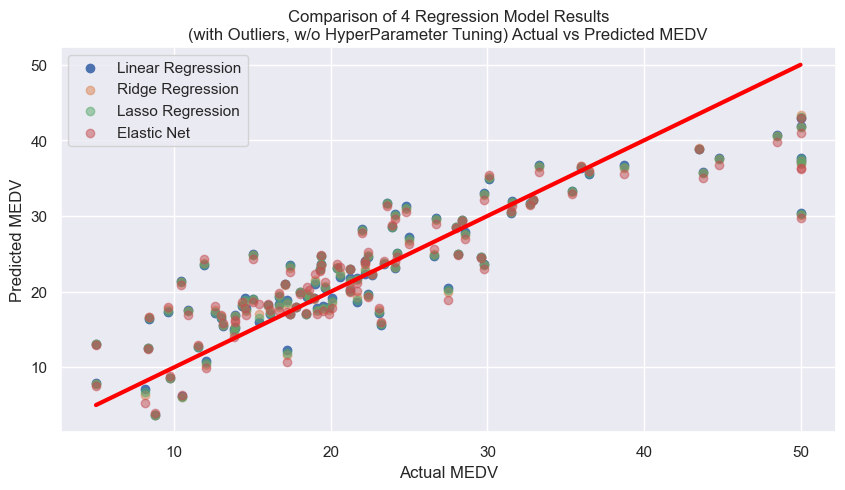

In [559]:
# Plot of the Predicted MEDV vs Actual MEDV
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.5)
plt.scatter(y_test, y_pred_lasso, label='Lasso Regression', alpha=0.5)
plt.scatter(y_test, y_pred_elastic, label='Elastic Net', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=3)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.legend()
plt.title('Comparison of 4 Regression Model Results\n(with Outliers, w/o HyperParameter Tuning) Actual vs Predicted MEDV')
plt.savefig('Scatterplot_LinearRegression_WithoutHT_WithOutliers.png', dpi=1200)
plt.show()

In [560]:
# Mean squared Error and RMSE is so high on regression models results without filtering outlier across all 4 regression models
# R^2 is lowered by a slight margin mostly only lower by 0.01-0.03.
# Means so much error compared to the actual value.
# Less accurate, outliers can hinder the predictive value precision.
# It is a lesson, to remove the outliers most of the times that it makes complete sense to remove the outliers.